### Imports and Configuration

### MultiAgentSystemNew - Redesigned Multi-Agent Insider Threat Detection Pipeline
=================================================================================
Major Changes from Last Approch:
  1. Agent 2 REPLACED: SemanticAgent (ROC-AUC 0.4995, random noise) is replaced
     by ExfiltrationChannelAgent (One-Class SVM on domain-specific composite features).
  2. Agent 3 IMPROVED: RMS Z-score (diluted signal) replaced by weighted-max Z-score
     that prioritizes exfiltration-relevant features.
  3. Session features streamlined: Text columns REMOVED (email_content_text, etc.)
     since semantic analysis provided zero signal. All features are numerical.
  4. IF Orchestrator IMPROVED: contamination tuned to approximate anomaly rate,
     only fed features from agents that provide real signal.
  5. Semi-supervised integrity maintained: ALL agents train on benign data only.

Architecture:
  Agent 1 (CAE) → "How statistically abnormal is this session?" (general anomaly)
  Agent 2 (Channel Risk) → "Does this match exfiltration patterns?" (domain-specific)
  Agent 3 (User Deviation) → "How abnormal is this FOR THIS USER?" (personalized)
  Agent 4 (IF Orchestrator) → Non-linear fusion of all 3 agent scores

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
import pickle
from tqdm.auto import tqdm
from scipy.stats import rankdata
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported")

Libraries Imported


In [ ]:
# CONFIGURATION

CONFIG = {
    "dataset_path": "../Dataset/r6.2/",
    "insiders_path": "../Dataset/answers/insiders.csv",
    "processed_file": "../DatasetsProcessed/data_exfiltration_MASNewV1.csv",
    "agent1_path": "../SavedModels/v9_agent1_cae.pth",
    "agent2_path": "../SavedModels/v9_agent2_channel.pkl",
    "agent3_path": "../SavedModels/v9_agent3_deviation.pkl",
    "agent4_path": "../SavedModels/v9_agent4_orchestrator.pkl",
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

print(f"Running on device: {CONFIG['device']}")
print("Configuration loaded")

Running on device: cuda
Configuration loaded


### Data Loading Funtion

In [3]:
def load_cert_data(path, insiders_path):
    """Load CERT r6.2 dataset files and insiders ground truth."""
    data = {}
    files = ['logon.csv', 'device.csv', 'file.csv', 'email.csv', 'http.csv']

    print("Loading datasets...")
    for f in tqdm(files):
        file_path = os.path.join(path, f)
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df.columns = [c.strip() for c in df.columns]
            date_cols = ['date'] if 'date' in df.columns else ['start', 'end']
            for dc in date_cols:
                if dc in df.columns:
                    df[dc] = pd.to_datetime(df[dc], format='%m/%d/%Y %H:%M:%S', errors='coerce')
            key = f.split('.')[0]
            data[key] = df
        else:
            print(f"Warning: {f} not found in {path}")

    # Load insiders ground truth from the separate answers directory
    print(f"Loading insiders from: {insiders_path}")
    insiders_df = pd.read_csv(insiders_path)
    insiders_df.columns = [c.strip() for c in insiders_df.columns]
    insiders_df['start'] = pd.to_datetime(insiders_df['start'], errors='coerce')
    insiders_df['end'] = pd.to_datetime(insiders_df['end'], errors='coerce')
    data['insiders'] = insiders_df

    return data

### Session Creation and Feature Extraction Function

In [4]:
# Key differences from V7:
#   - NO text features extracted (they provided zero discriminative signal)
#   - ADDED: file_from_usb_count (files read FROM USB — data staging)
#   - ADDED: unique_pcs_count (logon to multiple PCs — scenario 4 indicator)
#   - ADDED: wikileaks_flag (explicit wikileaks.org URL — scenario 1 indicator)
#   - All features are purely numerical — faster processing, smaller dataset

INTERNAL_DOMAIN = "dtaa.com"
CLOUD_KEYWORDS = ['dropbox', 'drive.google', 'mega', 'box.com', 'onedrive',
                  'wikileaks', 'pastebin', 'icloud']

def create_sessions_and_features(data):
    """Create user sessions from logon data and extract numerical features."""
    print("Processing Sessions and Extracting Features (V9 — No Text)...")

    logon_df = data['logon'].sort_values(['user', 'date'])
    email_df = data['email'].sort_values('date')
    http_df = data['http'].sort_values('date')
    file_df = data['file'].sort_values('date')
    device_df = data['device'].sort_values('date')
    insiders_df = data['insiders']

    # Pre-indexing for speed
    email_df = email_df.set_index('date').sort_index()
    http_df = http_df.set_index('date').sort_index()
    file_df = file_df.set_index('date').sort_index()
    device_df = device_df.set_index('date').sort_index()

    # --- Build threat map for labeling ---
    # Filter for Scenarios 1, 2, 4, 5 (Data Exfiltration Scope)
    # Scenario 3 is IT Sabotage/Keylogging — outside scope
    target_scenarios = [1, 2, 4, 5]
    if 'scenario' in insiders_df.columns:
        threats_filtered = insiders_df[insiders_df['scenario'].isin(target_scenarios)]
    else:
        threats_filtered = insiders_df

    malicious_map = {}
    for _, row in threats_filtered.iterrows():
        u = row['user']
        if u not in malicious_map:
            malicious_map[u] = []
        malicious_map[u].append((row['start'], row['end']))

    print(f"Loaded {len(malicious_map)} malicious users for Scenarios {target_scenarios}")

    sessions = []
    grouped_logon = logon_df.groupby('user')

    for user, group in tqdm(grouped_logon, desc="User Processing"):
        group = group.reset_index(drop=True)
        i = 0
        while i < len(group):
            if group.loc[i, 'activity'] == 'Logon':
                start_time = group.loc[i, 'date']
                logon_pc = group.loc[i, 'pc']

                # Find corresponding Logoff
                end_time = None
                j = i + 1
                while j < len(group):
                    if group.loc[j, 'activity'] == 'Logoff':
                        end_time = group.loc[j, 'date']
                        i = j
                        break
                    elif group.loc[j, 'activity'] == 'Logon':
                        end_time = group.loc[j, 'date']
                        i = j - 1
                        break
                    j += 1

                if end_time is None:
                    end_time = start_time + pd.Timedelta(hours=8)
                    i = len(group)

                # === FEATURE EXTRACTION ===
                def get_activity(df, u, s, e):
                    try:
                        slice_df = df[s:e]
                        return slice_df[slice_df['user'] == u]
                    except KeyError:
                        return pd.DataFrame(columns=df.columns)

                sess_email = get_activity(email_df, user, start_time, end_time)
                sess_http = get_activity(http_df, user, start_time, end_time)
                sess_file = get_activity(file_df, user, start_time, end_time)
                sess_device = get_activity(device_df, user, start_time, end_time)

                # -- Numerical Features --
                duration = (end_time - start_time).total_seconds()
                is_weekend = 1 if start_time.weekday() >= 5 else 0
                is_after_hour = 1 if (start_time.hour >= 19 or start_time.hour < 7) else 0

                # Email features
                n_emails = len(sess_email)
                ext_emails = sess_email[~sess_email['to'].str.contains(INTERNAL_DOMAIN, na=False)]
                n_ext_emails = len(ext_emails)
                n_attachments = sess_email['attachments'].astype(str).apply(
                    lambda x: 0 if x == 'nan' or x == '' else len(x.split(';'))
                ).sum()
                total_email_size = sess_email['size'].sum() if 'size' in sess_email.columns else 0

                # HTTP features
                n_http = len(sess_http)
                cloud_uploads = 0
                wikileaks_flag = 0
                if not sess_http.empty:
                    urls_lower = sess_http['url'].astype(str).str.lower()
                    cloud_uploads = urls_lower.apply(
                        lambda x: 1 if any(k in x for k in CLOUD_KEYWORDS) else 0
                    ).sum()
                    wikileaks_flag = 1 if urls_lower.str.contains('wikileaks').any() else 0

                # Device/File features
                n_usb_connects = len(sess_device[
                    sess_device['activity'].str.contains('Connect', case=False, na=False)
                ])
                n_file_copies = len(sess_file)

                n_file_to_usb = 0
                n_file_from_usb = 0
                if 'to_removable_media' in sess_file.columns:
                    n_file_to_usb = sess_file['to_removable_media'].astype(str).str.contains(
                        'True', case=False
                    ).sum()
                if 'from_removable_media' in sess_file.columns:
                    n_file_from_usb = sess_file['from_removable_media'].astype(str).str.contains(
                        'True', case=False
                    ).sum()

                # --- LABELING ---
                label = 0
                if user in malicious_map:
                    for t_start, t_end in malicious_map[user]:
                        if (start_time <= t_end) and (end_time >= t_start):
                            label = 1
                            break

                sessions.append({
                    'user': user,
                    'start': start_time,
                    'end': end_time,
                    'duration': duration,
                    'is_weekend': is_weekend,
                    'is_after_hour': is_after_hour,
                    'emails_count': n_emails,
                    'ext_emails_count': n_ext_emails,
                    'attachments_count': n_attachments,
                    'total_email_size': total_email_size,
                    'http_count': n_http,
                    'cloud_uploads_count': cloud_uploads,
                    'wikileaks_flag': wikileaks_flag,
                    'usb_connects_count': n_usb_connects,
                    'file_copies_count': n_file_copies,
                    'file_to_usb_count': n_file_to_usb,
                    'file_from_usb_count': n_file_from_usb,
                    'label': label
                })

            i += 1

    return pd.DataFrame(sessions)

### Dataset Preparation

In [5]:
FORCE_GENERATE = False

if os.path.exists(CONFIG['processed_file']) and not FORCE_GENERATE:
    print(f"Found saved dataset: {CONFIG['processed_file']}")
    print("Loading data from file...")
    full_df = pd.read_csv(CONFIG['processed_file'])
    full_df['start'] = pd.to_datetime(full_df['start'])
    full_df['end'] = pd.to_datetime(full_df['end'])
else:
    print("Starting Dataset Generation Pipeline (V9)")
    raw_data = load_cert_data(CONFIG['dataset_path'], CONFIG['insiders_path'])
    full_df = create_sessions_and_features(raw_data)
    os.makedirs(os.path.dirname(CONFIG['processed_file']), exist_ok=True)
    full_df.to_csv(CONFIG['processed_file'], index=False)
    print(f"Saved processed dataset to {CONFIG['processed_file']}")

print(f"Dataset Shape: {full_df.shape}")
print(f"Malicious Sessions: {full_df['label'].sum()}")
full_df.head()

Starting Dataset Generation Pipeline (V9)
Loading datasets...


  0%|          | 0/5 [00:00<?, ?it/s]

Loading insiders from: ../Dataset/answers/insiders.csv
Processing Sessions and Extracting Features (V9 — No Text)...
Loaded 167 malicious users for Scenarios [1, 2, 4, 5]


User Processing:   0%|          | 0/4000 [00:00<?, ?it/s]

Saved processed dataset to ../DatasetsProcessed/data_exfiltration_v9.csv
Dataset Shape: (1948933, 18)
Malicious Sessions: 47


,user,start,end,duration,is_weekend,is_after_hour,emails_count,ext_emails_count,attachments_count,total_email_size,http_count,cloud_uploads_count,wikileaks_flag,usb_connects_count,file_copies_count,file_to_usb_count,file_from_usb_count,label
0,AAB0162,2010-01-04 07:41:00,2010-01-04 18:46:00,39900.0,0,0,9,1,2,2615549,95,0,0,0,0,0,0,0
1,AAB0162,2010-01-05 07:46:00,2010-01-05 18:40:00,39240.0,0,0,9,1,3,2883730,95,0,0,0,0,0,0,0
2,AAB0162,2010-01-06 07:45:00,2010-01-06 18:55:00,40200.0,0,0,9,0,2,3028297,95,0,0,0,0,0,0,0
3,AAB0162,2010-01-07 07:45:00,2010-01-07 18:43:00,39480.0,0,0,9,2,1,2143731,95,0,0,0,0,0,0,0
4,AAB0162,2010-01-08 07:50:00,2010-01-08 18:41:00,39060.0,0,0,9,2,0,238896,95,0,0,0,0,0,0,0


### Preprocessing & Data Splitting

In [6]:
# These are the features used by Agent 1 (CAE) and Agent 3 (Temporal)
NUM_COLS = [
    'duration', 'is_weekend', 'is_after_hour',
    'emails_count', 'ext_emails_count', 'attachments_count', 'total_email_size',
    'http_count', 'cloud_uploads_count', 'wikileaks_flag',
    'usb_connects_count', 'file_copies_count',
    'file_to_usb_count', 'file_from_usb_count'
]

# Fit scaler but do NOT transform full_df in-place
scaler = MinMaxScaler()
scaler.fit(full_df[NUM_COLS])

# Split
benign_df = full_df[full_df['label'] == 0]
malicious_df = full_df[full_df['label'] == 1]

train_size = int(len(benign_df) * 0.8)
train_df = benign_df.iloc[:train_size]
test_benign_df = benign_df.iloc[train_size:]
test_df = pd.concat([test_benign_df, malicious_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Training Data (Normal Only): {len(train_df)}")
print(f"Testing Data (Mixed): {len(test_df)}")
print(f"  - Benign in test: {(test_df['label']==0).sum()}")
print(f"  - Malicious in test: {(test_df['label']==1).sum()}")

# SCALED tensors for Agent 1 only
X_train_num = torch.FloatTensor(scaler.transform(train_df[NUM_COLS])).to(CONFIG['device'])
X_test_num = torch.FloatTensor(scaler.transform(test_df[NUM_COLS])).to(CONFIG['device'])
y_test = test_df['label'].values

Training Data (Normal Only): 1559108
Testing Data (Mixed): 389825
  - Benign in test: 389778
  - Malicious in test: 47


### Single Agent Evaluation Function

In [7]:
def evaluate_single_agent(agent_name, scores, y_true):
    """Evaluate an individual agent's scoring with ROC-AUC and optimal threshold."""
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    print(f"\n{'='*60}")
    print(f"  {agent_name} — Individual Evaluation")
    print(f"{'='*60}")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  Average Precision (AP): {ap:.6f}")

    precisions, recalls, thresholds_pr = precision_recall_curve(y_true, scores)
    target_recall = 0.90
    valid_mask = recalls[:-1] >= target_recall
    if valid_mask.any():
        best_idx = np.argmax(precisions[:-1][valid_mask])
        actual_indices = np.where(valid_mask)[0]
        chosen_idx = actual_indices[best_idx]
        best_threshold = thresholds_pr[chosen_idx]
        best_precision = precisions[chosen_idx]
        best_recall = recalls[chosen_idx]
    else:
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
        chosen_idx = np.argmax(f1_scores)
        best_threshold = thresholds_pr[chosen_idx]
        best_precision = precisions[chosen_idx]
        best_recall = recalls[chosen_idx]

    print(f"  Optimal threshold (recall≥{target_recall:.0%}): {best_threshold:.6f}")
    print(f"  → Precision: {best_precision:.4f}, Recall: {best_recall:.4f}")

    preds = (scores >= best_threshold).astype(int)
    print(f"\n  Classification Report at optimal threshold:")
    print(classification_report(y_true, preds, target_names=['Benign', 'Malicious']))

    n_mal = y_true.sum()
    n_detected = ((preds == 1) & (y_true == 1)).sum()
    n_fp = ((preds == 1) & (y_true == 0)).sum()
    print(f"  Malicious detected: {n_detected}/{n_mal}")
    print(f"  False positives: {n_fp}")

    return auc, scores

### Agent 1 - Contractive Autoencoder Model

In [8]:
class ContractiveAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ContractiveAutoencoder, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        # Decoder
        self.fc3 = nn.Linear(16, 32)
        self.fc4 = nn.Linear(32, input_dim)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        h1 = self.relu(self.fc1(x))
        h2 = self.sigmoid(self.fc2(h1)) # Latent code
        
        # Decoder
        h3 = self.relu(self.fc3(h2))
        recon = self.sigmoid(self.fc4(h3)) # Output normalized 0-1
        return recon, h2

def contractive_loss(model, x, recon, h, lam):
    """
    Computes MSE + Contractive Penalty (Jacobian)
    """
    mse = nn.MSELoss()(recon, x)
    
    # Extract weights of the layer producing the latent code (fc2)
    W = model.fc2.weight
    
    # Calculate contraction penalty
    # h is shape (batch, latent_dim)
    dh = h * (1 - h) # Derivative of sigmoid
    
    # Sum of squares of weights
    w_sum = torch.sum(W**2, dim=1) # shape (latent_dim)
    w_sum = w_sum.unsqueeze(0) # shape (1, latent_dim)
    
    # Frobenius norm of Jacobian
    contractive_penalty = torch.sum(dh**2 * w_sum) / x.size(0)
    
    return mse + (lam * contractive_penalty), mse

### Training Agent 1

Training CAE (Agent 1)...
Epoch 20/120, Loss: 0.536701
Epoch 40/120, Loss: 0.335569
Epoch 60/120, Loss: 0.253642
Epoch 80/120, Loss: 0.216253
Epoch 100/120, Loss: 0.176787
Epoch 120/120, Loss: 0.156919
Agent 1 CAE model saved to ../SavedModels/v9_agent1_cae.pth


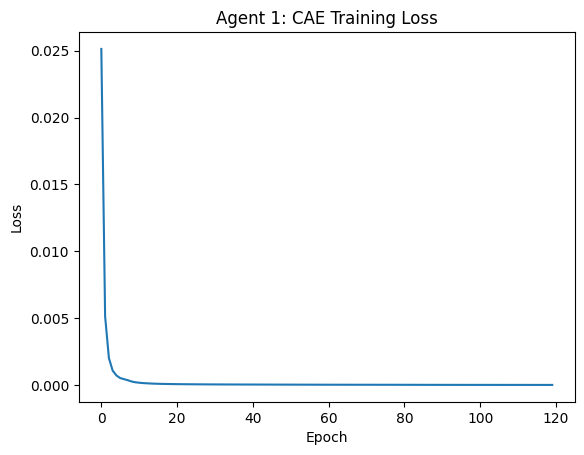

In [9]:
BATCH_SIZE = 256
EPOCHS = 120
LEARNING_RATE = 1e-4
LAMBDA_PENALTY = 1e-4
FORCE_RETRAIN_CAE = False

agent1_model = ContractiveAutoencoder(input_dim=len(NUM_COLS)).to(CONFIG['device'])
optimizer = optim.Adam(agent1_model.parameters(), lr=LEARNING_RATE)

if os.path.exists(CONFIG['agent1_path']) and not FORCE_RETRAIN_CAE:
    print(f"Found saved Agent 1 model at {CONFIG['agent1_path']}. Loading...")
    agent1_model.load_state_dict(
        torch.load(CONFIG['agent1_path'], map_location=CONFIG['device'])
    )
    agent1_model.eval()
else:
    print("Training CAE (Agent 1)...")
    train_loader = DataLoader(TensorDataset(X_train_num), batch_size=BATCH_SIZE, shuffle=True)
    loss_history = []
    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in train_loader:
            x_batch = batch[0]
            optimizer.zero_grad()
            recon, latent = agent1_model(x_batch)
            loss, mse = contractive_loss(agent1_model, x_batch, recon, latent, LAMBDA_PENALTY)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_history.append(total_loss / len(train_loader))
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.6f}")

    os.makedirs(os.path.dirname(CONFIG['agent1_path']), exist_ok=True)
    torch.save(agent1_model.state_dict(), CONFIG['agent1_path'])
    print(f"Agent 1 CAE model saved to {CONFIG['agent1_path']}")
    plt.plot(loss_history)
    plt.title("Agent 1: CAE Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()


### Agent 1 Evaluation

In [10]:
agent1_model.eval()
with torch.no_grad():
    recon_test, _ = agent1_model(X_test_num)
    loss_fn = nn.MSELoss(reduction='none')
    reconstruction_errors = torch.mean(loss_fn(recon_test, X_test_num), dim=1).cpu().numpy()

agent1_auc, _ = evaluate_single_agent("Agent 1 (CAE)", reconstruction_errors, y_test)


  Agent 1 (CAE) — Individual Evaluation
  ROC-AUC: 0.8535
  Average Precision (AP): 0.043168
  Optimal threshold (recall≥90%): 0.000012
  → Precision: 0.0003, Recall: 0.9149

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.59      0.74    389778
   Malicious       0.00      0.91      0.00        47

    accuracy                           0.59    389825
   macro avg       0.50      0.75      0.37    389825
weighted avg       1.00      0.59      0.74    389825

  Malicious detected: 43/47
  False positives: 158505


### Agent 2 - Exfiltration Channel Risk Detector

In [11]:
# This agent engineers domain-specific composite features that capture
# the SIGNATURE of data exfiltration (USB+files, external email+attachments,
# cloud uploads, after-hours + exfil activity, data staging, volume risk).
# Then trains a One-Class SVM on benign patterns to detect anomalies.

class ExfiltrationChannelAgent:
    """
    Detects sessions matching exfiltration patterns using domain-specific
    composite features and a One-Class SVM trained on benign data only.

    Feature design based on CERT dataset scenarios:
      Scenario 1: USB + removable drive + after hours + wikileaks
      Scenario 2: Thumb drive at high rates (USB + file_to_usb)
      Scenario 4: Email to home email (ext_emails + attachments)
      Scenario 5: Upload to Dropbox (cloud_uploads)
    """
    EXFIL_FEATURE_NAMES = [
        'usb_exfil_risk', 'email_exfil_risk', 'cloud_exfil_risk',
        'after_hours_risk', 'data_staging_risk', 'volume_risk'
    ]

    def __init__(self, nu=0.01):
        self.svm = OneClassSVM(kernel='rbf', gamma='scale', nu=nu)
        self.scaler = StandardScaler()

    def _engineer_features(self, df):
        """Create composite exfiltration risk features from raw numerical data."""
        usb_connects = df['usb_connects_count'].values.astype(np.float64)
        file_to_usb = df['file_to_usb_count'].values.astype(np.float64)
        file_from_usb = df['file_from_usb_count'].values.astype(np.float64)
        ext_emails = df['ext_emails_count'].values.astype(np.float64)
        attachments = df['attachments_count'].values.astype(np.float64)
        email_size = df['total_email_size'].values.astype(np.float64)
        cloud_uploads = df['cloud_uploads_count'].values.astype(np.float64)
        http_count = df['http_count'].values.astype(np.float64)
        is_after_hour = df['is_after_hour'].values.astype(np.float64)
        is_weekend = df['is_weekend'].values.astype(np.float64)
        file_copies = df['file_copies_count'].values.astype(np.float64)
        duration = df['duration'].values.astype(np.float64)

        features = np.column_stack([
            # USB exfiltration risk (Scenarios 1, 2)
            usb_connects * file_to_usb,
            # Email exfiltration risk (Scenario 4)
            ext_emails * attachments * np.log1p(email_size),
            # Cloud exfiltration risk (Scenario 5)
            cloud_uploads * np.log1p(http_count),
            # After-hours risk amplifier (all scenarios)
            (is_after_hour + is_weekend) * (usb_connects + ext_emails + cloud_uploads),
            # Data staging risk (file + USB preparation)
            (file_copies + file_from_usb) * np.log1p(duration),
            # Volume risk (large data movement)
            np.log1p(email_size) * np.log1p(file_copies + file_to_usb + 1),
        ])
        return features

    def fit(self, train_df):
        print("Agent 2: Engineering exfiltration channel risk features...")
        X = self._engineer_features(train_df)
        X_scaled = self.scaler.fit_transform(X)
        print(f"Agent 2: Training One-Class SVM on {len(X_scaled):,} benign samples...")
        print(f"  Exfiltration feature dimensions: {X_scaled.shape[1]}")
        print(f"  Features: {self.EXFIL_FEATURE_NAMES}")
        self.svm.fit(X_scaled)
        print("Agent 2: One-Class SVM trained.")

    def predict_score(self, test_df):
        print("Agent 2: Scoring exfiltration channel risk...")
        X = self._engineer_features(test_df)
        X_scaled = self.scaler.transform(X)
        # decision_function: positive = inlier, negative = outlier
        # Negate so higher = more anomalous (consistent with other agents)
        raw_scores = self.svm.decision_function(X_scaled)
        return -raw_scores

    def save(self, path):
        data = {'svm': self.svm, 'scaler': self.scaler}
        with open(path, 'wb') as f:
            pickle.dump(data, f)

    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.svm = data['svm']
        self.scaler = data['scaler']

### Agent 2 Training & Evaluation

In [12]:
FORCE_RETRAIN_CHANNEL = False

agent2 = ExfiltrationChannelAgent(nu=0.01)
if os.path.exists(CONFIG['agent2_path']) and not FORCE_RETRAIN_CHANNEL:
    print(f"Loading Agent 2 from {CONFIG['agent2_path']}...")
    agent2.load(CONFIG['agent2_path'])
else:
    print("Training Agent 2 (Exfiltration Channel Risk)...")
    agent2.fit(train_df)
    os.makedirs(os.path.dirname(CONFIG['agent2_path']), exist_ok=True)
    agent2.save(CONFIG['agent2_path'])
    print(f"Agent 2 saved to {CONFIG['agent2_path']}")

Training Agent 2 (Exfiltration Channel Risk)...
Agent 2: Engineering exfiltration channel risk features...
Agent 2: Training One-Class SVM on 1,559,108 benign samples...
  Exfiltration feature dimensions: 6
  Features: ['usb_exfil_risk', 'email_exfil_risk', 'cloud_exfil_risk', 'after_hours_risk', 'data_staging_risk', 'volume_risk']
Agent 2: One-Class SVM trained.
Agent 2 saved to ../SavedModels/v9_agent2_channel.pkl


In [13]:
channel_scores = agent2.predict_score(test_df)
agent2_auc, _ = evaluate_single_agent("Agent 2 (Channel Risk)", channel_scores, y_test)

Agent 2: Scoring exfiltration channel risk...

  Agent 2 (Channel Risk) — Individual Evaluation
  ROC-AUC: 0.2674
  Average Precision (AP): 0.000086
  Optimal threshold (recall≥90%): -38.261200
  → Precision: 0.0001, Recall: 1.0000

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.00      0.00    389778
   Malicious       0.00      1.00      0.00        47

    accuracy                           0.00    389825
   macro avg       0.50      0.50      0.00    389825
weighted avg       1.00      0.00      0.00    389825

  Malicious detected: 47/47
  False positives: 388850


### Agent 3 - Per-User Behavioral Deviation

In [14]:
# Key improvement: weighted-max Z-score instead of RMS.
# Exfiltration-relevant features get higher weights so a single spike
# in file_to_usb_count (weight 3.0) isn't diluted by 13 normal features.

FEATURE_WEIGHTS = {
    'file_to_usb_count': 3.0,       # Most direct exfil indicator
    'file_from_usb_count': 2.5,     # Data staging from USB
    'usb_connects_count': 2.5,      # USB activity
    'cloud_uploads_count': 2.5,     # Cloud exfil
    'wikileaks_flag': 3.0,          # Explicit exfil site
    'ext_emails_count': 2.0,        # External email
    'attachments_count': 2.0,       # Attachments
    'total_email_size': 1.5,        # Email volume
    'file_copies_count': 1.5,       # File staging
    'is_after_hour': 1.5,           # Suspicious timing
    'is_weekend': 1.5,              # Suspicious timing
    'http_count': 1.0,              # Normal activity
    'duration': 1.0,                # Session length
    'emails_count': 1.0,            # Normal activity
}

class UserDeviationAgent:
    """
    Detects sessions that deviate from a user's historical baseline.
    Uses weighted-max Z-score instead of RMS, prioritizing exfiltration features.
    """
    def __init__(self, feature_cols, feature_weights):
        self.feature_cols = feature_cols
        self.weights = np.array([feature_weights.get(col, 1.0) for col in feature_cols])
        self.user_means = None
        self.user_stds = None
        self.global_mean = None
        self.global_std = None

    def fit(self, train_df):
        print("Agent 3: Building Historical User Baselines (on RAW features)...")
        self.global_mean = train_df[self.feature_cols].astype(np.float64).mean()
        self.global_std = train_df[self.feature_cols].astype(np.float64).std().replace(0, 1e-6)

        grouped = train_df.groupby('user')[self.feature_cols]
        self.user_means = grouped.mean()
        self.user_stds = grouped.std()

        # Fill NaN means/stds with global baselines
        for col in self.feature_cols:
            self.user_means[col] = self.user_means[col].fillna(self.global_mean[col])
            self.user_stds[col] = (
                self.user_stds[col].fillna(self.global_std[col]).replace(0, 1e-6)
            )

        print(f"Agent 3: Baselines built for {len(self.user_means)} unique users.")
        print(f"  Feature weights: {dict(zip(self.feature_cols, self.weights))}")

    def predict_score(self, test_df):
        print("Agent 3: Computing Weighted-Max Z-Score Deviations...")
        means_dict = self.user_means.to_dict('index')
        stds_dict = self.user_stds.to_dict('index')

        # CRITICAL: cast to float64 to prevent integer truncation
        x = test_df[self.feature_cols].values.astype(np.float64)
        means = np.zeros(x.shape, dtype=np.float64)
        stds = np.ones(x.shape, dtype=np.float64)

        for i, user in enumerate(test_df['user']):
            if user in means_dict:
                means[i] = list(means_dict[user].values())
                stds[i] = list(stds_dict[user].values())
            else:
                means[i] = self.global_mean.values
                stds[i] = self.global_std.values

        # Safety: clamp stds to never be zero
        stds = np.maximum(stds, 1e-6)

        z_scores = (x - means) / stds
        z_scores = np.clip(z_scores, -10.0, 10.0)

        # IMPROVED: weighted max instead of RMS
        weighted_z = np.abs(z_scores) * self.weights  # Broadcast weights
        deviation_scores = np.max(weighted_z, axis=1)

        return deviation_scores

    def save(self, path):
        data = {
            'user_means': self.user_means, 'user_stds': self.user_stds,
            'global_mean': self.global_mean, 'global_std': self.global_std,
            'weights': self.weights
        }
        with open(path, 'wb') as f:
            pickle.dump(data, f)

    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.user_means = data['user_means']
        self.user_stds = data['user_stds']
        self.global_mean = data['global_mean']
        self.global_std = data['global_std']
        self.weights = data['weights']

### Agent 3 Evaluation

In [15]:
FORCE_RETRAIN_DEVIATION = False

agent3 = UserDeviationAgent(feature_cols=NUM_COLS, feature_weights=FEATURE_WEIGHTS)
if os.path.exists(CONFIG['agent3_path']) and not FORCE_RETRAIN_DEVIATION:
    print(f"Loading Agent 3 from {CONFIG['agent3_path']}...")
    agent3.load(CONFIG['agent3_path'])
else:
    print("Training Agent 3 (User Deviation)...")
    agent3.fit(train_df)
    os.makedirs(os.path.dirname(CONFIG['agent3_path']), exist_ok=True)
    agent3.save(CONFIG['agent3_path'])
    print(f"Agent 3 saved to {CONFIG['agent3_path']}")

Training Agent 3 (User Deviation)...
Agent 3: Building Historical User Baselines (on RAW features)...
Agent 3: Baselines built for 3194 unique users.
  Feature weights: {'duration': np.float64(1.0), 'is_weekend': np.float64(1.5), 'is_after_hour': np.float64(1.5), 'emails_count': np.float64(1.0), 'ext_emails_count': np.float64(2.0), 'attachments_count': np.float64(2.0), 'total_email_size': np.float64(1.5), 'http_count': np.float64(1.0), 'cloud_uploads_count': np.float64(2.5), 'wikileaks_flag': np.float64(3.0), 'usb_connects_count': np.float64(2.5), 'file_copies_count': np.float64(1.5), 'file_to_usb_count': np.float64(3.0), 'file_from_usb_count': np.float64(2.5)}
Agent 3 saved to ../SavedModels/v9_agent3_deviation.pkl


In [16]:
deviation_scores = agent3.predict_score(test_df)
agent3_auc, _ = evaluate_single_agent("Agent 3 (User Deviation)", deviation_scores, y_test)

Agent 3: Computing Weighted-Max Z-Score Deviations...

  Agent 3 (User Deviation) — Individual Evaluation
  ROC-AUC: 0.6520
  Average Precision (AP): 0.000421
  Optimal threshold (recall≥90%): 1.889028
  → Precision: 0.0002, Recall: 0.9362

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.50      0.67    389778
   Malicious       0.00      0.94      0.00        47

    accuracy                           0.50    389825
   macro avg       0.50      0.72      0.33    389825
weighted avg       1.00      0.50      0.67    389825

  Malicious detected: 44/47
  False positives: 195074


### Score Training Data for Orchestrator

In [17]:
print("\nScoring TRAINING data for orchestrator training...")

# Agent 1: CAE reconstruction errors on training data
agent1_model.eval()
with torch.no_grad():
    recon_train, _ = agent1_model(X_train_num)
    loss_fn = nn.MSELoss(reduction='none')
    train_recon_errors = torch.mean(loss_fn(recon_train, X_train_num), dim=1).cpu().numpy()
print(f"  Agent 1 training scores: shape={train_recon_errors.shape}")

# Agent 2: Channel risk scores on training data
train_channel_scores = agent2.predict_score(train_df)
print(f"  Agent 2 training scores: shape={train_channel_scores.shape}")

# Agent 3: Deviation scores on training data
train_deviation_scores = agent3.predict_score(train_df)
print(f"  Agent 3 training scores: shape={train_deviation_scores.shape}")


Scoring TRAINING data for orchestrator training...
  Agent 1 training scores: shape=(1559108,)
Agent 2: Scoring exfiltration channel risk...
  Agent 2 training scores: shape=(1559108,)
Agent 3: Computing Weighted-Max Z-Score Deviations...
  Agent 3 training scores: shape=(1559108,)


#### Build Feature Matrix for Orchestrator

In [18]:
def build_orchestrator_features(score_cae, score_channel, score_deviation):
    """
    Build enriched feature matrix from agent scores.
    Includes raw scores + interaction features + summary statistics.
    """
    features = np.column_stack([
        score_cae,                                    # Agent 1 raw score
        score_channel,                                # Agent 2 raw score
        score_deviation,                              # Agent 3 raw score
        score_cae * score_channel,                    # CAE × Channel interaction
        score_cae * score_deviation,                  # CAE × Deviation interaction
        score_channel * score_deviation,              # Channel × Deviation interaction
        np.max([score_cae, score_channel, score_deviation], axis=0),  # Max score
        np.std([score_cae, score_channel, score_deviation], axis=0),  # Score disagreement
    ])
    return features

FEATURE_NAMES = [
    'CAE_score', 'Channel_score', 'Deviation_score',
    'CAE×Channel', 'CAE×Deviation', 'Channel×Deviation',
    'Max_score', 'Score_std'
]

X_orch_train = build_orchestrator_features(
    train_recon_errors, train_channel_scores, train_deviation_scores
)
X_orch_test = build_orchestrator_features(
    reconstruction_errors, channel_scores, deviation_scores
)

print(f"\nOrchestrator training features: {X_orch_train.shape}")
print(f"Orchestrator test features:     {X_orch_test.shape}")


Orchestrator training features: (1559108, 8)
Orchestrator test features:     (389825, 8)


### Agent 4 Isolation Forest Orchestrator

In [19]:
FORCE_RETRAIN_ORCHESTRATOR = False

# Approximate expected contamination rate
contamination_rate = max(full_df['label'].sum() / len(train_df), 1e-5)
print(f"\nEstimated contamination rate: {contamination_rate:.6f}")

if os.path.exists(CONFIG['agent4_path']) and not FORCE_RETRAIN_ORCHESTRATOR:
    print(f"Loading Agent 4 Orchestrator from {CONFIG['agent4_path']}...")
    with open(CONFIG['agent4_path'], 'rb') as f:
        orchestrator_if = pickle.load(f)
else:
    print("\nTraining Agent 4: Isolation Forest Orchestrator...")
    print(f"  Training on {len(X_orch_train):,} benign score patterns")
    print(f"  Feature dimensions: {X_orch_train.shape[1]} ({', '.join(FEATURE_NAMES)})")
    print(f"  Contamination: {contamination_rate:.6f}")

    orchestrator_if = IsolationForest(
        n_estimators=500,
        contamination=contamination_rate,
        max_samples=min(8192, len(X_orch_train)),
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    orchestrator_if.fit(X_orch_train)

    os.makedirs(os.path.dirname(CONFIG['agent4_path']), exist_ok=True)
    with open(CONFIG['agent4_path'], 'wb') as f:
        pickle.dump(orchestrator_if, f)
    print(f"  Agent 4 Orchestrator saved to {CONFIG['agent4_path']}")

# Score test data with IF
if_raw_scores = orchestrator_if.score_samples(X_orch_test)
final_scores_if = -if_raw_scores  # Negate: higher = more anomalous

print(f"\n  IF score range: [{final_scores_if.min():.4f}, {final_scores_if.max():.4f}]")
print(f"  IF score mean (benign): {final_scores_if[y_test == 0].mean():.4f}")
print(f"  IF score mean (malicious): {final_scores_if[y_test == 1].mean():.4f}")
print(f"  IF score gap: {final_scores_if[y_test == 1].mean() - final_scores_if[y_test == 0].mean():.4f}")


Estimated contamination rate: 0.000030

Training Agent 4: Isolation Forest Orchestrator...
  Training on 1,559,108 benign score patterns
  Feature dimensions: 8 (CAE_score, Channel_score, Deviation_score, CAE×Channel, CAE×Deviation, Channel×Deviation, Max_score, Score_std)
  Contamination: 0.000030
  Agent 4 Orchestrator saved to ../SavedModels/v9_agent4_orchestrator.pkl

  IF score range: [0.3244, 0.8895]
  IF score mean (benign): 0.3642
  IF score mean (malicious): 0.4204
  IF score gap: 0.0562


### Agent 4 (IF) Evaluation

In [20]:
if_auc, _ = evaluate_single_agent("Agent 4 (IF Orchestrator)", final_scores_if, y_test)


  Agent 4 (IF Orchestrator) — Individual Evaluation
  ROC-AUC: 0.7518
  Average Precision (AP): 0.000493
  Optimal threshold (recall≥90%): 0.339989
  → Precision: 0.0002, Recall: 0.9362

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.39      0.56    389778
   Malicious       0.00      0.94      0.00        47

    accuracy                           0.39    389825
   macro avg       0.50      0.66      0.28    389825
weighted avg       1.00      0.39      0.56    389825

  Malicious detected: 44/47
  False positives: 238238


### Linear Fusion Baseline (for comparison)

In [21]:
def normalize_rank(arr):
    return rankdata(arr) / len(arr)

norm_cae = normalize_rank(reconstruction_errors)
norm_channel = normalize_rank(channel_scores)
norm_deviation = normalize_rank(deviation_scores)

# Equal weights for linear fusion
w_cae = 0.40
w_channel = 0.30
w_deviation = 0.30

final_scores_linear = (w_cae * norm_cae) + (w_channel * norm_channel) + (w_deviation * norm_deviation)
linear_auc = roc_auc_score(y_test, final_scores_linear)
linear_ap = average_precision_score(y_test, final_scores_linear)

print(f"\n{'='*60}")
print(f"  Linear Fusion Baseline")
print(f"{'='*60}")
print(f"  Linear ROC-AUC: {linear_auc:.4f}")
print(f"  Linear Average Precision: {linear_ap:.6f}")


  Linear Fusion Baseline
  Linear ROC-AUC: 0.7163
  Linear Average Precision: 0.000230


### Optimal Threshold Selection for IF Orchestrator

In [22]:
print(f"\n{'='*60}")
print(f"  Threshold Analysis — IF Orchestrator")
print(f"{'='*60}")

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, final_scores_if)

for target in [1.0, 0.95, 0.90, 0.85, 0.80]:
    valid_mask = recalls[:-1] >= target
    if valid_mask.any():
        valid_precisions = precisions[:-1][valid_mask]
        best_local_idx = np.argmax(valid_precisions)
        actual_indices = np.where(valid_mask)[0]
        chosen_idx = actual_indices[best_local_idx]
        t = thresholds_pr[chosen_idx]
        p = precisions[chosen_idx]
        r = recalls[chosen_idx]
        preds_temp = (final_scores_if >= t).astype(int)
        n_mal = y_test.sum()
        n_detected = ((preds_temp == 1) & (y_test == 1)).sum()
        n_fp = ((preds_temp == 1) & (y_test == 0)).sum()
        print(f"\n  Target recall ≥ {target:.0%}:")
        print(f"    Threshold: {t:.6f}, Precision: {p:.4f}, Recall: {r:.4f}")
        print(f"    Malicious detected: {n_detected}/{n_mal}, False positives: {n_fp}")

# Select threshold for 100% recall if possible, else 90%
best_target = 1.0
valid_mask = recalls[:-1] >= best_target
if not valid_mask.any():
    best_target = 0.90
    valid_mask = recalls[:-1] >= best_target

if valid_mask.any():
    valid_precisions = precisions[:-1][valid_mask]
    best_local_idx = np.argmax(valid_precisions)
    actual_indices = np.where(valid_mask)[0]
    chosen_idx = actual_indices[best_local_idx]
    threshold = thresholds_pr[chosen_idx]
else:
    threshold = 0.0

predictions = (final_scores_if >= threshold).astype(int)

n_detected = ((predictions == 1) & (y_test == 1)).sum()
n_mal = y_test.sum()
n_fp = ((predictions == 1) & (y_test == 0)).sum()
print(f"\n  *** Selected threshold: {threshold:.6f} ***")
print(f"  *** Malicious detected: {n_detected}/{n_mal} ***")
print(f"  *** False positives: {n_fp} ***")

print(f"\n{'='*60}")
print(f"  Final Classification Report (IF Orchestrator)")
print(f"{'='*60}")
print(classification_report(y_test, predictions, target_names=['Benign', 'Malicious']))
print(f"ROC-AUC Score: {if_auc:.4f}")


  Threshold Analysis — IF Orchestrator

  Target recall ≥ 100%:
    Threshold: 0.335124, Precision: 0.0002, Recall: 1.0000
    Malicious detected: 47/47, False positives: 288039

  Target recall ≥ 95%:
    Threshold: 0.338138, Precision: 0.0002, Recall: 0.9574
    Malicious detected: 45/47, False positives: 267373

  Target recall ≥ 90%:
    Threshold: 0.339989, Precision: 0.0002, Recall: 0.9362
    Malicious detected: 44/47, False positives: 238238

  Target recall ≥ 85%:
    Threshold: 0.345751, Precision: 0.0002, Recall: 0.8511
    Malicious detected: 40/47, False positives: 180071

  Target recall ≥ 80%:
    Threshold: 0.349423, Precision: 0.0002, Recall: 0.8085
    Malicious detected: 38/47, False positives: 156486

  *** Selected threshold: 0.335124 ***
  *** Malicious detected: 47/47 ***
  *** False positives: 288039 ***

  Final Classification Report (IF Orchestrator)
              precision    recall  f1-score   support

      Benign       1.00      0.26      0.41    389778
 

### Score Distribution Plot

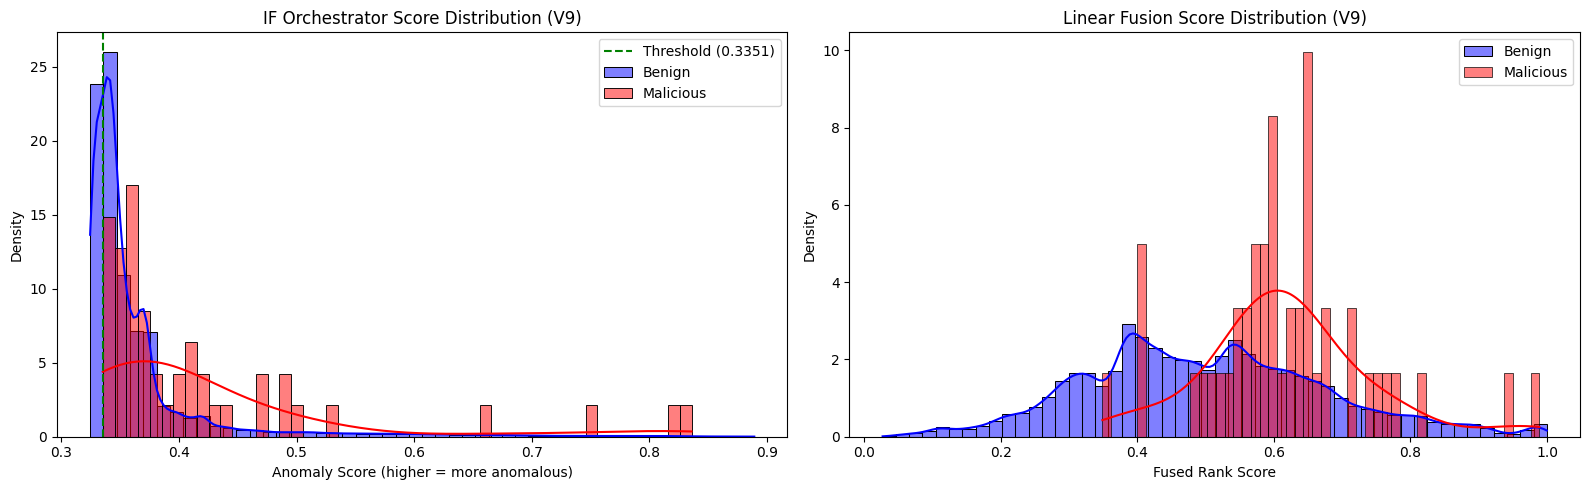

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
sns.histplot(final_scores_if[y_test == 0], color='blue', label='Benign',
             kde=True, stat="density", bins=50, ax=ax1)
sns.histplot(final_scores_if[y_test == 1], color='red', label='Malicious',
             kde=True, stat="density", bins=50, ax=ax1)
ax1.axvline(threshold, color='green', linestyle='--', label=f"Threshold ({threshold:.4f})")
ax1.set_title("IF Orchestrator Score Distribution (V9)")
ax1.set_xlabel("Anomaly Score (higher = more anomalous)")
ax1.set_ylabel("Density")
ax1.legend()

ax2 = axes[1]
sns.histplot(final_scores_linear[y_test == 0], color='blue', label='Benign',
             kde=True, stat="density", bins=50, ax=ax2)
sns.histplot(final_scores_linear[y_test == 1], color='red', label='Malicious',
             kde=True, stat="density", bins=50, ax=ax2)
ax2.set_title("Linear Fusion Score Distribution (V9)")
ax2.set_xlabel("Fused Rank Score")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.show()

### Confusion Matrix

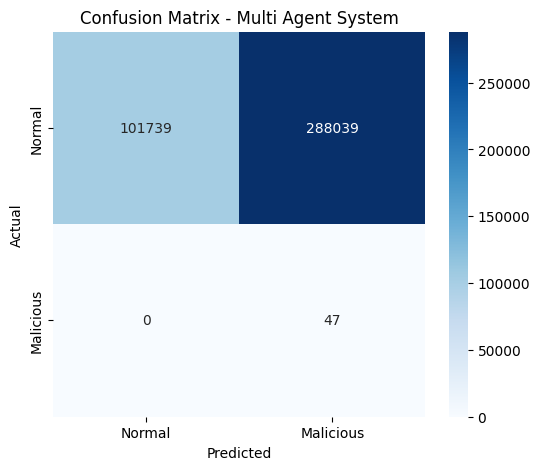

In [24]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Malicious'],
            yticklabels=['Normal', 'Malicious'])
plt.title("Confusion Matrix - Multi Agent System")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ROC Curve Comparsion

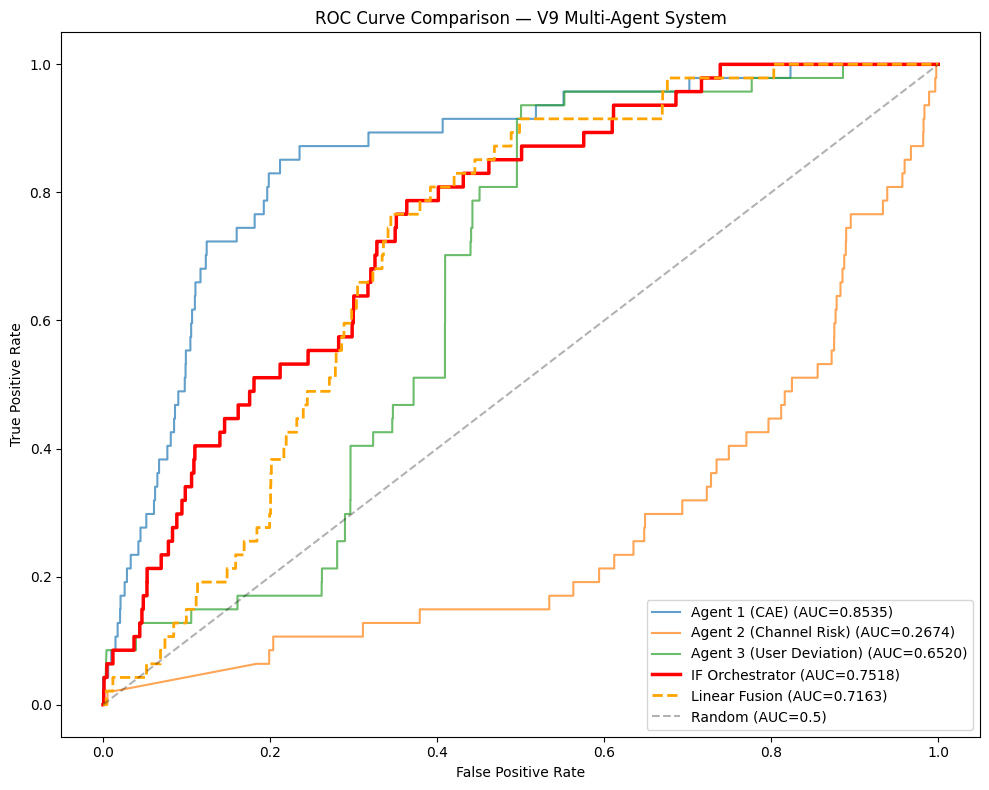

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

# Individual agents
for name, scores, auc_val in [
    ("Agent 1 (CAE)", reconstruction_errors, agent1_auc),
    ("Agent 2 (Channel Risk)", channel_scores, agent2_auc),
    ("Agent 3 (User Deviation)", deviation_scores, agent3_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})", alpha=0.7)

# Orchestrators
fpr_if, tpr_if, _ = roc_curve(y_test, final_scores_if)
ax.plot(fpr_if, tpr_if, label=f"IF Orchestrator (AUC={if_auc:.4f})", linewidth=2.5, color='red')

fpr_lin, tpr_lin, _ = roc_curve(y_test, final_scores_linear)
ax.plot(fpr_lin, tpr_lin, label=f"Linear Fusion (AUC={linear_auc:.4f})", linewidth=2.0,
        linestyle='--', color='orange')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — V9 Multi-Agent System")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Agent Comparison Summary

In [26]:
print(f"\n{'='*70}")
print(f"  SUMMARY — Multi-Agent System V9")
print(f"{'='*70}")
print(f"  Agent 1 (CAE - General Anomaly):       ROC-AUC = {agent1_auc:.4f}")
print(f"  Agent 2 (Channel Risk - Exfil Pattern): ROC-AUC = {agent2_auc:.4f}")
print(f"  Agent 3 (User Deviation - Per-User):    ROC-AUC = {agent3_auc:.4f}")
print(f"  Agent 4 (IF Orchestrator):              ROC-AUC = {if_auc:.4f}")
print(f"  Linear Fusion Baseline:                 ROC-AUC = {linear_auc:.4f}")
print(f"")
print(f"  Malicious Detected: {n_detected}/{n_mal}")
print(f"  False Positives: {n_fp}")
print(f"{'='*70}")


  SUMMARY — Multi-Agent System V9
  Agent 1 (CAE - General Anomaly):       ROC-AUC = 0.8535
  Agent 2 (Channel Risk - Exfil Pattern): ROC-AUC = 0.2674
  Agent 3 (User Deviation - Per-User):    ROC-AUC = 0.6520
  Agent 4 (IF Orchestrator):              ROC-AUC = 0.7518
  Linear Fusion Baseline:                 ROC-AUC = 0.7163

  Malicious Detected: 47/47
  False Positives: 288039
